In [1]:
%pip install librosa soundfile pandas scikit-learn seaborn pydub --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import warnings
import hashlib

from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, lfilter
from tqdm import tqdm
import tensorflow as tf

from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Dense, Reshape, Bidirectional, GRU,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    average_precision_score, hamming_loss,
    roc_curve, auc, precision_recall_curve
)

from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [ ]:
dataset_path = r'S:\sem8\Sound-Threat-Detection-System\model\Dataset'
classes = os.listdir(dataset_path)
print(classes)

['drone', 'gunshot', 'jetplane', 'vehicle']


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASSES = ["drone", "gunshot", "jetplane", "vehicle"]
NUM_CLASSES = len(CLASSES)

SR = 22050             
DURATION = 6            
SAMPLES = SR * DURATION 
N_MELS = 128           
N_FFT = 2048          
HOP_LENGTH = 512       
BATCH_SIZE = 32        
EPOCHS = 20            
LEARNING_RATE = 1e-4   
# THRESHOLD = 0.5        

ORIGINAL_DATASET  = r'S:\sem8\Sound-Threat-Detection-System\model\Dataset'
GENERATED_ROOT   = r'S:\sem8\Sound-Threat-Detection-System\model\generated_multilabel'
NOISE_DIR     = r'S:\sem8\Sound-Threat-Detection-System\model\noise' 
MODEL_SAVE_PATH  = r'S:\sem8\Sound-Threat-Detection-System\model\multilabel_model.keras'
SPLIT_CSV_PATH   = r'S:\sem8\Sound-Threat-Detection-System\model\split.csv'

NUM_MIXES_TRAIN = 6000   
NUM_MIXES_VAL   = 1200   
NUM_MIXES_TEST  = 1200  
NUM_HARD_TEST  = 500      
MIN_CLASSES_MIX = 2
MAX_CLASSES_MIX = 3
print("Config loaded.")
print(f"Classes: {CLASSES}")
print(f"SR={SR}, Duration={DURATION}s, Samples={SAMPLES}")

Config loaded.
Classes: ['drone', 'gunshot', 'jetplane', 'vehicle']
SR=22050, Duration=6s, Samples=132300


In [5]:
for cls in CLASSES:
  cls_path = Path(ORIGINAL_DATASET) / cls
  if cls_path.exists():
    count = len(list(cls_path.glob("*.wav")))
    print(f"{cls}: {count} files")
  else:
    print(f"{cls}: DIRECTORY NOT FOUND")

drone: 2388 files
gunshot: 2321 files
jetplane: 2497 files
vehicle: 2930 files


In [ ]:
csv_files = [
    r"S:\sem8\Sound-Threat-Detection-System\model\generated_multilabel\train\combined_metadata.csv",
    r"S:\sem8\Sound-Threat-Detection-System\model\generated_multilabel\test\combined_metadata.csv",
    r"S:\sem8\Sound-Threat-Detection-System\model\generated_multilabel\val\combined_metadata.csv"  
]

total_counts = {cls: 0 for cls in CLASSES}

for path in csv_files:
    df = pd.read_csv(path)

    for cls in CLASSES:
        if cls in df.columns:
            total_counts[cls] += df[cls].sum()

print("\nTotal class counts:\n")
for cls in CLASSES:
    print(f"{cls}: {int(total_counts[cls])} files")


Total class counts:

drone: 9517 files
gunshot: 6611 files
jetplane: 9532 files
vehicle: 7104 files


In [7]:
def compute_audio_hash(filepath, sr=SR, duration=3):
    try:
        y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
        y_quantized = np.round(y * 1000).astype(np.int16)
        return hashlib.md5(y_quantized.tobytes()).hexdigest()

    except:
        return None

def find_duplicates(dataset_root, classes):

    hash_to_files = defaultdict(list)
    all_files = []

    for cls in classes:
        cls_dir = Path(dataset_root) / cls
        if cls_dir.exists():
            for f in cls_dir.glob("*.wav"):
                all_files.append((str(f), cls))

    print(f"Computing hashes for {len(all_files)} files...")
    for filepath, cls in tqdm(all_files):
        h = compute_audio_hash(filepath)
        if h:
            hash_to_files[h].append((filepath, cls))

    duplicates = {k: v for k, v in hash_to_files.items() if len(v) > 1}
    total_dupes = sum(len(v) - 1 for v in duplicates.values())
    print(f"Found {len(duplicates)} duplicate groups ({total_dupes} extra files)")
   
    cross_class = 0
    for h, files in duplicates.items():
        classes_in_group = set(cls for _, cls in files)
        if len(classes_in_group) > 1:
            cross_class += 1
            print(f"  CROSS-CLASS DUPLICATE: {files}")
    print(f"Cross-class duplicates: {cross_class}")
    return duplicates

duplicates = find_duplicates(ORIGINAL_DATASET, CLASSES)

Computing hashes for 10136 files...


100%|██████████| 10136/10136 [01:32<00:00, 109.80it/s]

Found 217 duplicate groups (431 extra files)
  CROSS-CLASS DUPLICATE: [('S:\\sem8\\neww\\Dataset\\gunshot\\m4_100m_front_0608.wav', 'gunshot'), ('S:\\sem8\\neww\\Dataset\\jetplane\\06A2B1_2022-12-08_19-55-46_0_0_aug1.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\06A2B1_2022-12-11_13-33-24_0_0.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\06A2B1_2022-12-11_13-33-24_0_0_aug0.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\5001DE_2022-12-08_15-17-48_0_0.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\5001DE_2022-12-08_15-17-48_0_0_aug0.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\5001DE_2022-12-08_15-17-48_0_0_aug1.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\5001DE_2022-12-08_15-17-48_0_0_aug3.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\7C1A29_2022-12-08_20-32-21_0_0.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\7C1A29_2022-12-08_20-32-21_0_0_aug2.wav', 'jetplane'), ('S:\\sem8\\neww\\Dataset\\jetplane\\7C1CA2

In [8]:
import tensorflow.keras.backend as K

def weighted_binary_crossentropy(pos_weights, neg_weights=None):
    def loss(y_true, y_pred):
        epsilon = 1e-7
        y_pred = K.clip(y_pred, epsilon, 1 - epsilon)

        if neg_weights is None:
            neg_w = 1.0
        else:
            neg_w = neg_weights

        loss = - (
            pos_weights * y_true * K.log(y_pred) +
            neg_w * (1 - y_true) * K.log(1 - y_pred)
        )
        return K.mean(loss)
    return loss

pos_weights = np.array([
    1.2,  
    1.0, 
    0.8, 
    1.0  
])

neg_weights = np.array([
    1.0,
    1.0,
    1.5,  
    1.0
])

loss=weighted_binary_crossentropy(pos_weights, neg_weights)

In [9]:
def create_strict_split(dataset_root, output_csv, duplicates, train_ratio=0.7, val_ratio=0.15):
    dataset_root = Path(dataset_root)
    file_to_group = {}
    group_id = 0
    for h, files in duplicates.items():
        for filepath, cls in files:
            file_to_group[filepath] = group_id
        group_id += 1

    all_rows = []
    for cls in CLASSES:
        cls_dir = dataset_root / cls
        if not cls_dir.exists():
            print(f"WARNING: {cls_dir} not found")
            continue

        for f in sorted(cls_dir.glob("*.wav")):
            fp = str(f)
            if fp not in file_to_group:
                file_to_group[fp] = group_id
                group_id += 1

            all_rows.append({
                "filepath": fp,
                "label": cls,
                "group": file_to_group[fp]
            })

    df = pd.DataFrame(all_rows)
    groups = list(df["group"].unique())
    random.shuffle(groups)
    n = len(groups)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_groups = set(groups[:n_train])
    val_groups = set(groups[n_train:n_train + n_val])
    test_groups = set(groups[n_train + n_val:])

    def assign_split(g):
        if g in train_groups: return "train"
        if g in val_groups: return "val"
        return "test"

    df["split"] = df["group"].apply(assign_split)
    df.to_csv(output_csv, index=False)
    print(f"\nStrict split saved to: {output_csv}")
    print(df.groupby(["split", "label"]).size())

    train_files = set(df[df["split"] == "train"]["filepath"])
    val_files = set(df[df["split"] == "val"]["filepath"])
    test_files = set(df[df["split"] == "test"]["filepath"])
    assert len(train_files & val_files) == 0, "LEAKAGE: train-val overlap!"
    assert len(train_files & test_files) == 0, "LEAKAGE: train-test overlap!"
    assert len(val_files & test_files) == 0, "LEAKAGE: val-test overlap!"
    print("✓ NO LEAKAGE DETECTED")
    return df

split_df = create_strict_split(ORIGINAL_DATASET, SPLIT_CSV_PATH, duplicates)


Strict split saved to: S:\sem8\neww\split.csv
split  label   
test   drone        360
       gunshot      352
       jetplane     347
       vehicle      434
train  drone       1682
       gunshot     1589
       jetplane    1792
       vehicle     2083
val    drone        346
       gunshot      380
       jetplane     358
       vehicle      413
dtype: int64
✓ NO LEAKAGE DETECTED


In [10]:
def load_audio_safe(path, sr=SR):
  try:
    y, _ = librosa.load(path, sr=sr, mono=True)
    return y.astype(np.float32)

  except Exception as e:
    print(f"Error loading {path}: {e}")
    return None

def normalize_audio(y):
  peak = np.max(np.abs(y))
  if peak > 0:
    y = y / peak * 0.95
  return y

def pad_or_crop(y, target_len=SAMPLES):
  if len(y) == target_len:
    return y

  if len(y) > target_len:
    start = random.randint(0, len(y) - target_len)
    return y[start:start + target_len]

  pad_total = target_len - len(y)
  pad_left = random.randint(0, pad_total)
  pad_right = pad_total - pad_left
  return np.pad(y, (pad_left, pad_right), mode='constant')

def place_randomly(y, total_len=SAMPLES):
  if len(y) > total_len:
    y = pad_or_crop(y, total_len)
  out = np.zeros(total_len, dtype=np.float32)
  max_offset = total_len - len(y)
  offset = random.randint(0, max(0, max_offset))
  out[offset:offset + len(y)] += y
  return out, offset

def random_gain(y, min_g=0.3, max_g=1.0):
  gain = random.uniform(min_g, max_g)
  return y * gain, gain

def add_gaussian_noise(y, min_std=0.001, max_std=0.01):
  std = random.uniform(min_std, max_std)
  noise = np.random.randn(len(y)).astype(np.float32) * std
  return y + noise

def time_shift(y, max_shift=3000):
  shift = random.randint(-max_shift, max_shift)
  return np.roll(y, shift)

def pitch_shift_audio(y, sr=SR, max_steps=2.0):
  steps = random.uniform(-max_steps, max_steps)
  return librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

def time_stretch_audio(y, min_rate=0.85, max_rate=1.15):
  rate = random.uniform(min_rate, max_rate)
  stretched = librosa.effects.time_stretch(y, rate=rate)
  return pad_or_crop(stretched, SAMPLES)

def lowpass_filter(y, cutoff=4000, sr=SR, order=5):
  nyq = 0.5 * sr
  normal_cutoff = min(cutoff / nyq, 0.99)
  b, a = butter(order, normal_cutoff, btype='low', analog=False)
  return lfilter(b, a, y).astype(np.float32)

def highpass_filter(y, cutoff=300, sr=SR, order=3):
  nyq = 0.5 * sr
  normal_cutoff = max(cutoff / nyq, 0.01)
  b, a = butter(order, normal_cutoff, btype='high', analog=False)
  return lfilter(b, a, y).astype(np.float32)

def add_noise_at_snr(signal, noise, snr_db):
  sig_power = np.mean(signal ** 2) + 1e-10
  noise_power = np.mean(noise ** 2) + 1e-10
  scale = np.sqrt(sig_power / (10 ** (snr_db / 10) * noise_power))
  return signal + noise * scale

def fit_noise_to_length(noise, target_len):
  if len(noise) >= target_len:
    start = random.randint(0, len(noise) - target_len)
    return noise[start:start + target_len]

  repeats = int(np.ceil(target_len / len(noise)))
  tiled = np.tile(noise, repeats)
  return tiled[:target_len]

def augment_audio(y, sr=SR):
  if random.random() < 0.5:
    y = add_gaussian_noise(y)

  if random.random() < 0.5:
    y, _ = random_gain(y, 0.6, 1.2)

  if random.random() < 0.4:
    y = time_shift(y, max_shift=2000)

  if random.random() < 0.25:
    y = pitch_shift_audio(y, sr)

  if random.random() < 0.25:
    y = time_stretch_audio(y)

  if random.random() < 0.2:
    y = lowpass_filter(y, cutoff=random.randint(3000, 6000))

  if random.random() < 0.15:
    y = highpass_filter(y, cutoff=random.randint(100, 500))

  return normalize_audio(y)

print("Audio utilities loaded.")

Audio utilities loaded.


In [11]:
def load_noise_files(noise_dir):
  noise_dir = Path(noise_dir)
  if not noise_dir.exists():
    print(f"Noise dir not found: {noise_dir}")
    return []

  files = list(noise_dir.glob("*.wav"))
  print(f"Found {len(files)} noise files")
  return files

def build_split_class_dict(split_df, split_name):
  sub = split_df[split_df["split"] == split_name]
  class_files = {}
  for cls in CLASSES:
    files = sub[sub["label"] == cls]["filepath"].tolist()
    class_files[cls] = files
  return class_files

def generate_one_mix(class_files, noise_files=None,
  min_cls=MIN_CLASSES_MIX, max_cls=MAX_CLASSES_MIX,
  hard_mode=False,
  overlap_mode="hybrid"
):

  if random.random() < 0.15:  
    mix = np.zeros(SAMPLES, dtype=np.float32)

    noise = np.random.randn(SAMPLES).astype(np.float32)

    if random.random() < 0.5:
        noise = lowpass_filter(noise, cutoff=random.randint(500, 4000))
    if random.random() < 0.5:
        noise = highpass_filter(noise, cutoff=random.randint(100, 1000))

    mix = add_noise_at_snr(mix, noise, random.uniform(5, 15))
    mix = normalize_audio(mix)

    labels = {cls: 0 for cls in CLASSES}

    meta = {
        "sources": [],
        "noise_file": "synthetic",
        "snr_db": 0,
        "empty_sample": True
    }

    return mix, labels, meta

  n_classes = random.randint(min_cls, max_cls)

  weighted_classes = (
    ["drone"] * 2 +
    ["jetplane"] * 1 +
    ["gunshot"] * 1 +
    ["vehicle"] * 1
  )

  chosen = random.sample(weighted_classes, n_classes)
  chosen = list(set(chosen))

  mix = np.zeros(SAMPLES, dtype=np.float32)
  meta = {"sources": []}

  if "drone" in chosen and "jetplane" in chosen:
    use_overlap = random.random() < 0.3  
  else:
    if overlap_mode == "hybrid":
      use_overlap = random.random() < 0.6
    elif overlap_mode == "overlap":
      use_overlap = True
    else:
      use_overlap = False

  if use_overlap:
    overlap_len = random.randint(int(0.5 * SR), int(2.5 * SR))
    overlap_start = random.randint(0, SAMPLES - overlap_len)

  for cls in chosen:
    if len(class_files[cls]) == 0:
      continue

    src_path = random.choice(class_files[cls])
    y = load_audio_safe(src_path)
    if y is None:
      continue

    min_event = int(0.5 * SR)
    max_event = min(len(y), SAMPLES)
    event_len = random.randint(min_event, max_event) if max_event > min_event else max_event
    y = pad_or_crop(y, event_len)

    if cls in ["drone", "jetplane"]:
      y, g = random_gain(y, 0.5, 1.2)
    elif hard_mode:
      y, g = random_gain(y, 0.15, 0.7)
    else:
      y, g = random_gain(y, 0.3, 1.0)

    if use_overlap:
      y = pad_or_crop(y, overlap_len)
      placed = np.zeros(SAMPLES, dtype=np.float32)
      placed[overlap_start:overlap_start + overlap_len] += y
      offset = overlap_start
    else:
      placed, offset = place_randomly(y, SAMPLES)

    mix += placed

    meta["sources"].append({
      "class": cls,
      "file": src_path,
      "gain": g,
      "offset": offset,
      "event_len": event_len
    })

  if noise_files and len(noise_files) > 0 and random.random() < 0.7:
    nf = random.choice(noise_files)
    noise = load_audio_safe(str(nf))
    if noise is not None:
      noise = fit_noise_to_length(noise, SAMPLES)
      snr_db = random.uniform(-3, 8) if hard_mode else random.uniform(3, 20)
      mix = add_noise_at_snr(mix, noise, snr_db)
  else:
    if random.random() < 0.5:
      mix = add_gaussian_noise(mix, 0.001, 0.01)

  mix = normalize_audio(mix)

  labels = {cls: int(cls in chosen) for cls in CLASSES}
  return mix, labels, meta

In [12]:
def generate_mixed_dataset_for_split(
  split_name, class_files, num_mixes, noise_files,
  output_root, hard_mode=False,
  overlap_mode="hybrid"
):

  audio_dir = Path(output_root) / split_name / "audio"
  audio_dir.mkdir(parents=True, exist_ok=True)
  rows = []
  prefix = "hard_" if hard_mode else "mix_"
  for i in tqdm(range(num_mixes), desc=f"{split_name} {'(hard)' if hard_mode else ''}"):
    mix, labels, meta = generate_one_mix(
      class_files, noise_files, hard_mode=hard_mode, overlap_mode=overlap_mode
    )
    fname = f"{prefix}{split_name}_{i:06d}.wav"
    fpath = str(audio_dir / fname)
    sf.write(fpath, mix, SR)
    row = {"filepath": fpath}
    for cls in CLASSES:
      row[cls] = labels[cls]

    chosen_classes = [cls for cls in CLASSES if labels[cls] == 1]
    row["classes_present"] = ",".join(chosen_classes)
    row["num_classes"] = len(chosen_classes)
    row["hard_mode"] = int(hard_mode)
    row["noise_file"] = meta.get("noise_file", "")
    row["snr_db"] = meta.get("snr_db", -1)
    row["overlap_mode"] = meta.get("overlap_mode", "")
    rows.append(row)

  return pd.DataFrame(rows)

def generate_pure_multilabel_csv(split_df, split_name):
  sub = split_df[split_df["split"] == split_name].copy()
  rows = []
  for _, r in sub.iterrows():
    row = {"filepath": r["filepath"]}
    for cls in CLASSES:
      row[cls] = 1 if r["label"] == cls else 0
    row["classes_present"] = r["label"]
    row["num_classes"] = 1
    row["hard_mode"] = 0
    row["noise_file"] = ""
    row["snr_db"] = -1
    rows.append(row)
  return pd.DataFrame(rows)

In [13]:
print("Loading split CSV...")
split_df = pd.read_csv(SPLIT_CSV_PATH)
noise_files = load_noise_files(NOISE_DIR)
all_dfs = {}
for split_name in ["train", "val", "test"]:
  print(f"\n{'='*50}")
  print(f"Processing split: {split_name}")
  print(f"{'='*50}")
  class_files = build_split_class_dict(split_df, split_name)
  for cls in CLASSES:
    print(f" {cls}: {len(class_files[cls])} files")

  pure_df = generate_pure_multilabel_csv(split_df, split_name)
  print(f" Pure clips: {len(pure_df)}")

  num_mixes = {"train": NUM_MIXES_TRAIN, "val": NUM_MIXES_VAL, "test": NUM_MIXES_TEST}
  mix_df = generate_mixed_dataset_for_split(
    split_name,
    class_files,
    num_mixes[split_name],
    noise_files,
    GENERATED_ROOT,
    hard_mode=False,
    overlap_mode="hybrid"  
)

  print(f" Mixed clips: {len(mix_df)}")

  if split_name == "test":
    hard_df = generate_mixed_dataset_for_split(
      split_name,
      class_files,
      NUM_HARD_TEST,
      noise_files,
      GENERATED_ROOT,
      hard_mode=True,
      overlap_mode="overlap"  
    )
    print(f" Hard test clips: {len(hard_df)}")

  elif split_name == "train":
    hard_df = generate_mixed_dataset_for_split(
      split_name, class_files, int(NUM_MIXES_TRAIN * 0.2),
      noise_files, GENERATED_ROOT, hard_mode=True,
      overlap_mode="overlap"
    )

    print(f" Hard train clips: {len(hard_df)}")

  else:
    hard_df = pd.DataFrame()

  combined = pd.concat([pure_df, mix_df, hard_df], ignore_index=True)
  combined = combined.sample(frac=1, random_state=SEED).reset_index(drop=True)
  csv_path = Path(GENERATED_ROOT) / split_name / "combined_metadata.csv"
  csv_path.parent.mkdir(parents=True, exist_ok=True)
  combined.to_csv(csv_path, index=False)
  print(f" Combined total: {len(combined)}")
  print(f" Saved: {csv_path}")
  all_dfs[split_name] = combined

train_df = all_dfs["train"]
val_df = all_dfs["val"]
test_df = all_dfs["test"]
print("\n\nFinal dataset sizes:")
for name, df in all_dfs.items():
  print(f" {name}: {len(df)}")

Loading split CSV...
Noise dir not found: S:\sem8\neww\noise

Processing split: train
 drone: 1682 files
 gunshot: 1589 files
 jetplane: 1792 files
 vehicle: 2083 files
 Pure clips: 7146


train : 100%|██████████| 6000/6000 [00:49<00:00, 121.85it/s]


 Mixed clips: 6000


train (hard): 100%|██████████| 1200/1200 [00:08<00:00, 140.69it/s]


 Hard train clips: 1200
 Combined total: 14346
 Saved: S:\sem8\neww\generated_multilabel\train\combined_metadata.csv

Processing split: val
 drone: 346 files
 gunshot: 380 files
 jetplane: 358 files
 vehicle: 413 files
 Pure clips: 1497


...

 Mixed clips: 1200
 Combined total: 2697
 Saved: S:\sem8\neww\generated_multilabel\val\combined_metadata.csv

Processing split: test
 drone: 360 files
 gunshot: 352 files
 jetplane: 347 files
 vehicle: 434 files
 Pure clips: 1493


test : 100%|██████████| 1200/1200 [00:09<00:00, 121.31it/s]


 Mixed clips: 1200


test (hard): 100%|██████████| 500/500 [00:03<00:00, 134.26it/s]

 Hard test clips: 500
 Combined total: 3193
 Saved: S:\sem8\neww\generated_multilabel\test\combined_metadata.csv


Final dataset sizes:
 train: 14346
 val: 2697
 test: 3193


In [14]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
  print(f"\n{name.upper()} label distribution:")
  for cls in CLASSES:
    pos = df[cls].sum()
    total = len(df)
    print(f" {cls}: {pos}/{total} ({pos/total*100:.1f}%)")

  print(f" avg classes per sample: {df['num_classes'].mean():.2f}")


TRAIN label distribution:
 drone: 6632/14346 (46.2%)
 gunshot: 4626/14346 (32.2%)
 jetplane: 4837/14346 (33.7%)
 vehicle: 5123/14346 (35.7%)
 avg classes per sample: 1.48

VAL label distribution:
 drone: 1165/2697 (43.2%)
 gunshot: 875/2697 (32.4%)
 jetplane: 865/2697 (32.1%)
 vehicle: 921/2697 (34.1%)
 avg classes per sample: 1.42

TEST label distribution:
 drone: 1526/3193 (47.8%)
 gunshot: 1103/3193 (34.5%)
 jetplane: 1034/3193 (32.4%)
 vehicle: 1149/3193 (36.0%)
 avg classes per sample: 1.51


Mel shape: (128, 259)


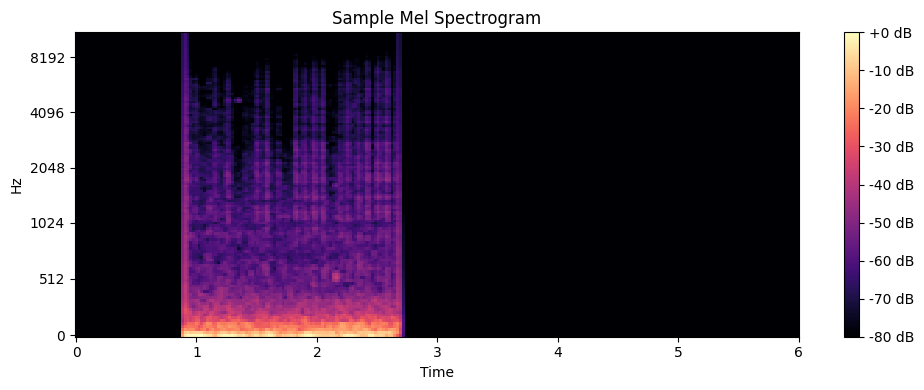

Expected time frames: 259
Input shape for model: (128, 259, 1)


In [15]:
def extract_mel_spectrogram(file_path, augment=False):
  y = load_audio_safe(file_path, sr=SR)
  if y is None:
    return np.zeros((N_MELS, 259), dtype=np.float32)

  y = pad_or_crop(y, SAMPLES)
  if augment:
    y = augment_audio(y, SR)

  mel = librosa.feature.melspectrogram(
    y=y, sr=SR, n_mels=N_MELS,
    n_fft=N_FFT, hop_length=HOP_LENGTH
  )
  mel_db = librosa.power_to_db(mel, ref=np.max)
  return mel_db.astype(np.float32)

sample_path = train_df.iloc[2]["filepath"]
sample_mel = extract_mel_spectrogram(sample_path)
print("Mel shape:", sample_mel.shape)
plt.figure(figsize=(10, 4))
librosa.display.specshow(sample_mel, sr=SR, x_axis='time', y_axis='mel',hop_length=HOP_LENGTH)
plt.colorbar(format='%+2.0f dB')
plt.title("Sample Mel Spectrogram")
plt.tight_layout()
plt.show()

EXPECTED_TIME_FRAMES = sample_mel.shape[1]
print(f"Expected time frames: {EXPECTED_TIME_FRAMES}")
print(f"Input shape for model: ({N_MELS}, {EXPECTED_TIME_FRAMES}, 1)")

In [16]:
class MultiLabelAudioGenerator(tf.keras.utils.Sequence):
  def __init__(self, df, batch_size=BATCH_SIZE, augment=False, shuffle=True, mean=None, std=None):
    self.df = df.reset_index(drop=True)
    self.batch_size = batch_size
    self.augment = augment
    self.shuffle = shuffle
    self.mean = mean
    self.std = std
    self.indexes = np.arange(len(self.df))
    self.on_epoch_end()

  def __len__(self):
    return int(np.ceil(len(self.df) / self.batch_size))

  def __getitem__(self, idx):
    batch_idx = self.indexes[
      idx * self.batch_size:(idx + 1) * self.batch_size
    ]
    batch_df = self.df.iloc[batch_idx]
    X_batch = []
    y_batch = []
    for _, row in batch_df.iterrows():
      mel = extract_mel_spectrogram(
        row["filepath"], augment=self.augment
      )

      if self.mean is not None and self.std is not None:
        mel = (mel - self.mean) / (self.std + 1e-8)

      mel = mel[..., np.newaxis] 
      label = row[CLASSES].values.astype(np.float32)
      X_batch.append(mel)
      y_batch.append(label)

    return np.array(X_batch), np.array(y_batch)

  def on_epoch_end(self):
    if self.shuffle:
      np.random.shuffle(self.indexes)

print("Data generator class defined.")

Data generator class defined.


In [17]:
def compute_normalization_stats(df, num_samples=500):
  subset = df.sample(n=min(num_samples, len(df)), random_state=SEED)
  all_mels = []
  for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Computing stats"):
    mel = extract_mel_spectrogram(row["filepath"], augment=False)
    all_mels.append(mel)

  all_mels = np.array(all_mels)
  mean = np.mean(all_mels)
  std = np.std(all_mels)
  print(f"Dataset mean: {mean:.4f}, std: {std:.4f}")
  return mean, std

MEAN, STD = compute_normalization_stats(train_df, num_samples=500)

Computing stats: 100%|██████████| 500/500 [00:07<00:00, 67.15it/s]


Dataset mean: -54.8714, std: 24.2891


In [18]:
train_gen = MultiLabelAudioGenerator(
  train_df, batch_size=BATCH_SIZE, augment=True,
  shuffle=True, mean=MEAN, std=STD
)
val_gen = MultiLabelAudioGenerator(
  val_df, batch_size=BATCH_SIZE, augment=False,
  shuffle=False, mean=MEAN, std=STD
)

test_gen = MultiLabelAudioGenerator(
  test_df, batch_size=BATCH_SIZE, augment=False,
  shuffle=False, mean=MEAN, std=STD
)

X_sample, y_sample = train_gen[0]
print(f"Batch X shape: {X_sample.shape}")
print(f"Batch y shape: {y_sample.shape}")
print(f"Sample labels: {y_sample[0]}")

Batch X shape: (32, 128, 259, 1)
Batch y shape: (32, 4)
Sample labels: [0. 0. 1. 0.]


In [19]:
def build_multilabel_cnn_bigru(input_shape, num_classes):
  inp = Input(shape=input_shape, name="mel_input")
  x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inp)
  x = BatchNormalization()(x)
  x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D((2, 2))(x)
  x = Dropout(0.2)(x)

  x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
  x = BatchNormalization()(x)
  x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D((2, 2))(x)
  x = Dropout(0.25)(x)

  x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
  x = BatchNormalization()(x)
  x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D((2, 2))(x)
  x = Dropout(0.3)(x)

  shape = x.shape
  x = Reshape((shape[1], shape[2] * shape[3]))(x)

  x = Bidirectional(GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
  x = Bidirectional(GRU(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
  x = GlobalAveragePooling1D()(x)
  x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
  x = Dropout(0.4)(x)
  x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
  x = Dropout(0.4)(x)

  out = Dense(num_classes, activation='sigmoid', name="output")(x)
  model = Model(inputs=inp, outputs=out)
  return model

INPUT_SHAPE = (N_MELS, EXPECTED_TIME_FRAMES, 1)
model = build_multilabel_cnn_bigru(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_input (InputLayer)          │ (None, 128, 259, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 259, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 259, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 259, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 259, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 129, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 129, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 129, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 129, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 129, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 129, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 4096)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 16, 256)        │     3,245,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 16, 128)        │       123,64

 Total params: 3,723,876 (14.21 MB)

 Trainable params: 3,722,980 (14.20 MB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=weighted_binary_crossentropy(pos_weights),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='bin_acc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc', multi_label=True)
    ]
)
print("Model compiled.")

Model compiled.


In [21]:
callbacks = [
  EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
  ),

  ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
  ),

  ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
  )
]

print("Callbacks defined.")

Callbacks defined.


In [22]:
history = model.fit(
  train_gen,
  validation_data=val_gen,
  epochs=EPOCHS,
  callbacks=callbacks,
  verbose=1
)
print("Training complete.")

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.6467 - bin_acc: 0.6535 - loss: 0.6817 - precision: 0.5429 - recall: 0.3976
Epoch 1: val_loss improved from None to 0.66207, saving model to S:\sem8\neww\multilabel_model.keras

Epoch 1: finished saving model to S:\sem8\neww\multilabel_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 1498s 3s/step - auc: 0.7136 - bin_acc: 0.6924 - loss: 0.6400 - precision: 0.6101 - recall: 0.4656 - val_auc: 0.7616 - val_bin_acc: 0.6726 - val_loss: 0.6621 - val_precision: 0.5494 - val_recall: 0.4276 - learning_rate: 1.0000e-04
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8165 - bin_acc: 0.7737 - loss: 0.5377 - precision: 0.7332 - recall: 0.6135
Epoch 2: val_loss improved from 0.66207 to 0.43717, saving model to S:\sem8\neww\multilabel_model.keras

Epoch 2: finished saving model to S:\sem8\neww\multilabel_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 1364s 3s/step - auc: 0.8383 - bin_acc: 0.7935 - loss: 0.5079 - precision: 0.7690 - recall: 0.63

In [23]:
import json
with open('training_history.json', 'w') as f:
    json.dump(history.history, f)

print("Training complete and history saved.")

Training complete and history saved.


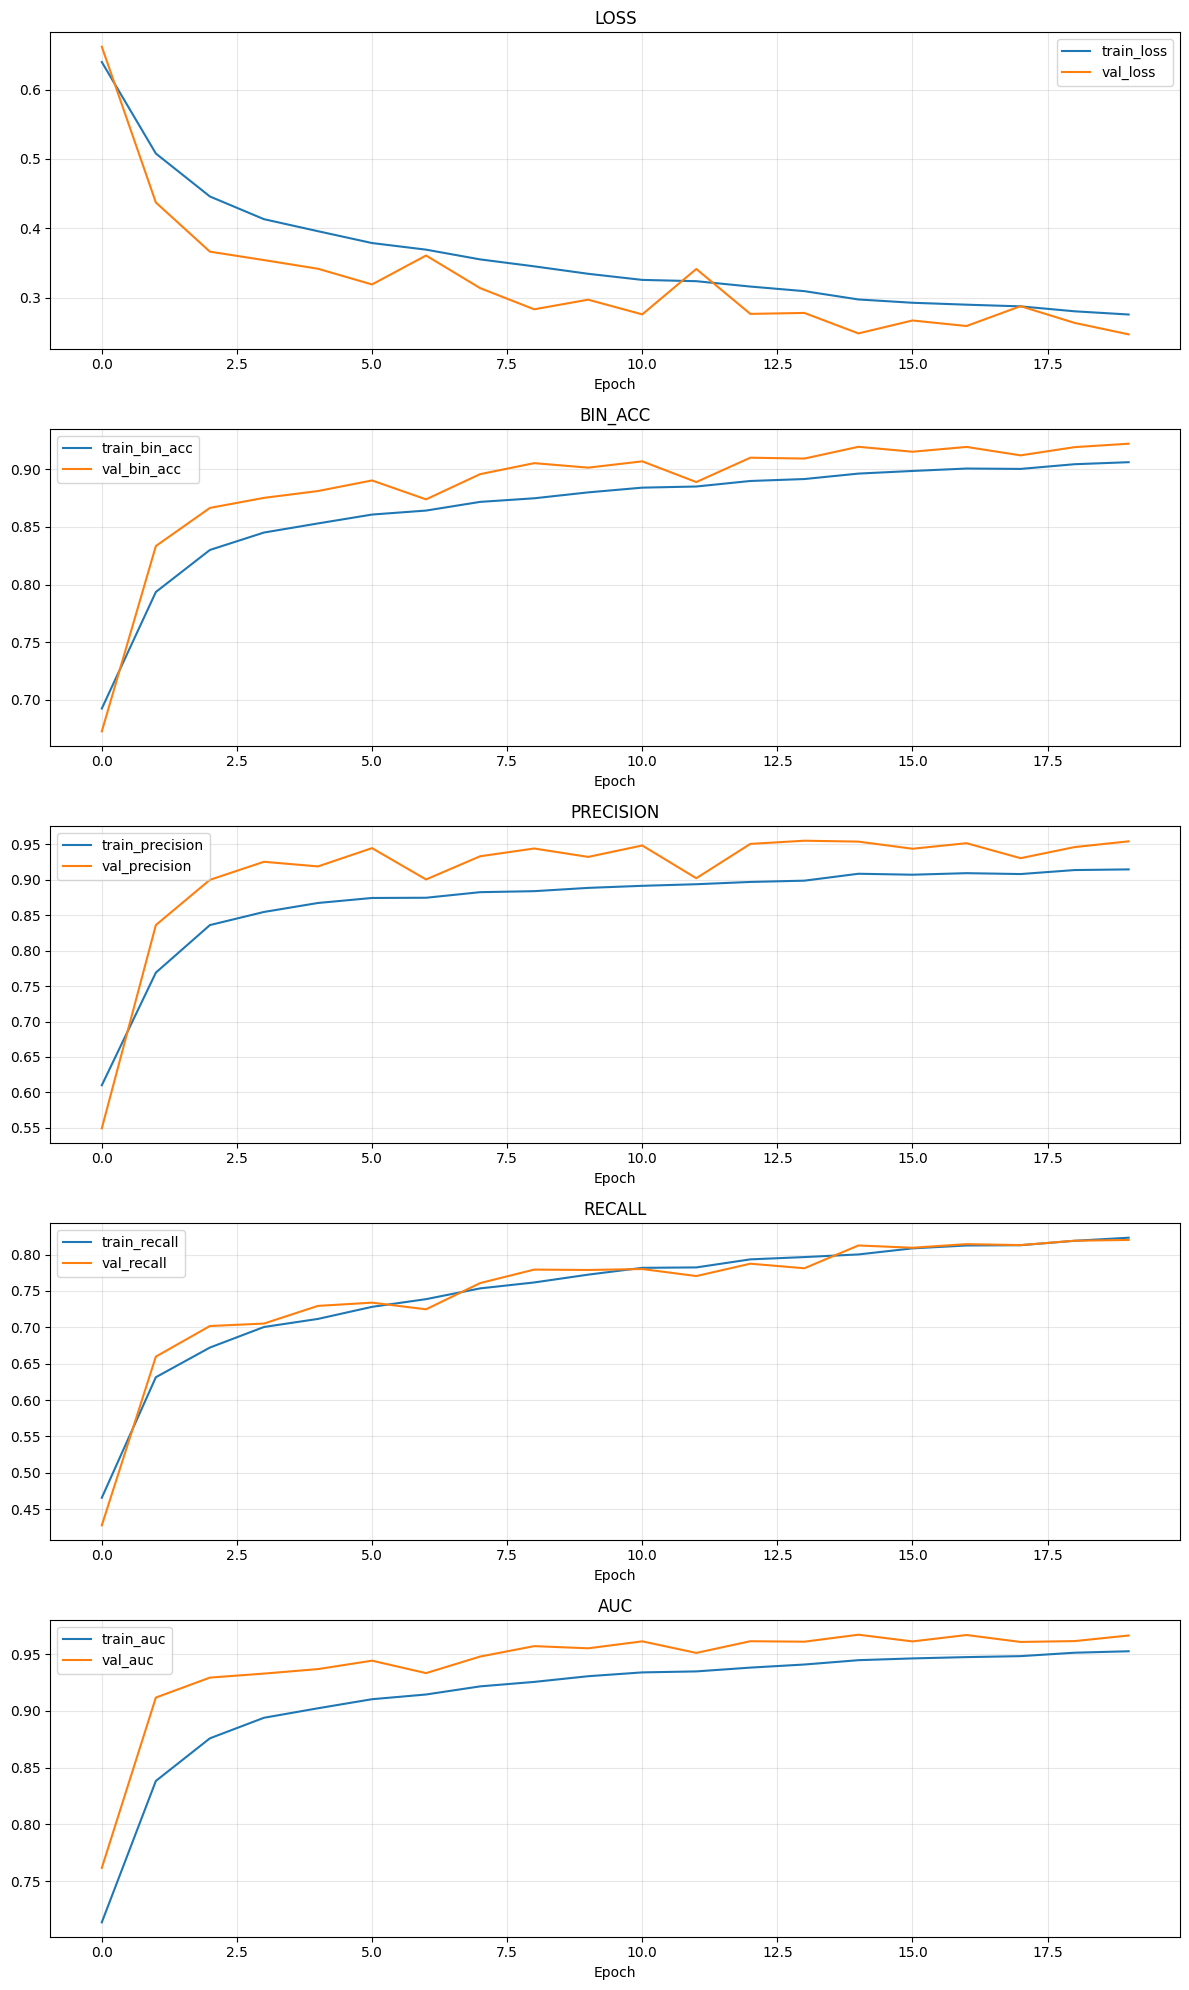

In [24]:
def plot_training_history(history):
  metrics = ['loss', 'bin_acc', 'precision', 'recall', 'auc']
  fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 4 * len(metrics)))
  for idx, metric in enumerate(metrics):
    ax = axes[idx]
    if metric in history.history:
      ax.plot(history.history[metric], label=f'train_{metric}')

    val_key = f'val_{metric}'
    if val_key in history.history:
      ax.plot(history.history[val_key], label=val_key)

    ax.set_title(metric.upper())
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

plot_training_history(history)

In [25]:
print("Evaluating on test set...")
test_results = model.evaluate(test_gen, verbose=1)
print("\nTest results:")
for name, val in zip(model.metrics_names, test_results):
  print(f" {name}: {val:.4f}")

y_true_list = []
y_pred_list = []

for i in tqdm(range(len(test_gen)), desc="Predicting"):
  X_batch, y_batch = test_gen[i]
  preds = model.predict(X_batch, verbose=0)
  y_true_list.append(y_batch)
  y_pred_list.append(preds)

y_true = np.vstack(y_true_list)
y_pred_probs = np.vstack(y_pred_list)
y_pred = np.zeros_like(y_pred_probs)

Evaluating on test set...
100/100 ━━━━━━━━━━━━━━━━━━━━ 94s 938ms/step - auc: 0.9538 - bin_acc: 0.9025 - loss: 0.2891 - precision: 0.9442 - recall: 0.7878

Test results:
 loss: 0.2891
 compile_metrics: 0.9025


Predicting: 100%|██████████| 100/100 [01:24<00:00,  1.18it/s]


In [26]:
def evaluate_multilabel(y_true, y_pred, y_pred_probs, classes, threshold=0.5):
  print("=" * 60)
  print("MULTI-LABEL EVALUATION RESULTS")
  print("=" * 60)

  print("\nClassification Report (per class):")
  print(classification_report(
    y_true, y_pred, target_names=classes, zero_division=0
  ))

  macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
  micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
  weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
  samples_f1 = f1_score(y_true, y_pred, average='samples', zero_division=0)

  macro_prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
  macro_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

  h_loss = hamming_loss(y_true, y_pred)

  exact_match = np.all(y_pred == y_true, axis=1).mean()

  print(f"\nMacro F1:    {macro_f1:.4f}")
  print(f"Micro F1:    {micro_f1:.4f}")
  print(f"Weighted F1:  {weighted_f1:.4f}")
  print(f"Samples F1:   {samples_f1:.4f}")
  print(f"Macro Precision:{macro_prec:.4f}")
  print(f"Macro Recall:  {macro_rec:.4f}")
  print(f"Hamming Loss:  {h_loss:.4f}")
  print(f"Exact Match:  {exact_match:.4f}")

  print(f"\nPer-class Average Precision (AP):")

  aps = []

  for i, cls in enumerate(classes):
    try:
      ap = average_precision_score(y_true[:, i], y_pred_probs[:, i])

    except:
      ap = 0.0

    aps.append(ap)
    print(f" {cls}: {ap:.4f}")

  mAP = np.mean(aps)
  print(f" mAP: {mAP:.4f}")

  return {
    "macro_f1": macro_f1,
    "micro_f1": micro_f1,
    "weighted_f1": weighted_f1,
    "samples_f1": samples_f1,
    "macro_precision": macro_prec,
    "macro_recall": macro_rec,
    "hamming_loss": h_loss,
    "exact_match": exact_match,
    "mAP": mAP
  }

results = evaluate_multilabel(y_true, y_pred, y_pred_probs, CLASSES)

MULTI-LABEL EVALUATION RESULTS

Classification Report (per class):
              precision    recall  f1-score   support

       drone       0.00      0.00      0.00      1526
     gunshot       0.00      0.00      0.00      1103
    jetplane       0.00      0.00      0.00      1034
     vehicle       0.00      0.00      0.00      1149

   micro avg       0.00      0.00      0.00      4812
   macro avg       0.00      0.00      0.00      4812
weighted avg       0.00      0.00      0.00      4812
 samples avg       0.00      0.00      0.00      4812


Macro F1:    0.0000
Micro F1:    0.0000
Weighted F1:  0.0000
Samples F1:   0.0000
Macro Precision:0.0000
Macro Recall:  0.0000
Hamming Loss:  0.3768
Exact Match:  0.0802

Per-class Average Precision (AP):
 drone: 0.9824
 gunshot: 0.9612
 jetplane: 0.8173
 vehicle: 0.9743
 mAP: 0.9338


In [27]:
def find_optimal_thresholds(y_true, y_pred_probs, classes):
  thresholds = np.arange(0.1, 0.9, 0.05)
  best_thresholds = {}
  for i, cls in enumerate(classes):
    best_t = 0.5
    best_f1 = 0.0
    for t in thresholds:
      preds = (y_pred_probs[:, i] >= t).astype(int)
      f1 = f1_score(y_true[:, i], preds, zero_division=0)
      if f1 > best_f1:
        best_f1 = f1
        best_t = t

    best_thresholds[cls] = {"threshold": best_t, "f1": best_f1}
    print(f"{cls}: best threshold={best_t:.2f}, F1={best_f1:.4f}")

  return best_thresholds

print("Optimal thresholds per class:")
optimal_thresholds = find_optimal_thresholds(y_true, y_pred_probs, CLASSES)
y_pred_optimal = np.zeros_like(y_pred)

for i, cls in enumerate(CLASSES):
  t = optimal_thresholds[cls]["threshold"]
  y_pred_optimal[:, i] = (y_pred_probs[:, i] >= t).astype(int)

print("\n\nResults with OPTIMAL thresholds:")
results_optimal = evaluate_multilabel(
  y_true, y_pred_optimal, y_pred_probs, CLASSES
)

Optimal thresholds per class:
drone: best threshold=0.25, F1=0.9357
gunshot: best threshold=0.20, F1=0.9003
jetplane: best threshold=0.25, F1=0.6964
vehicle: best threshold=0.55, F1=0.9174


Results with OPTIMAL thresholds:
MULTI-LABEL EVALUATION RESULTS

Classification Report (per class):
              precision    recall  f1-score   support

       drone       0.94      0.93      0.94      1526
     gunshot       0.95      0.86      0.90      1103
    jetplane       0.68      0.72      0.70      1034
     vehicle       0.93      0.90      0.92      1149

   micro avg       0.88      0.86      0.87      4812
   macro avg       0.87      0.85      0.86      4812
weighted avg       0.88      0.86      0.87      4812
 samples avg       0.87      0.83      0.83      4812


Macro F1:    0.8625
Micro F1:    0.8702
Weighted F1:  0.8718
Samples F1:   0.8326
Macro Precision:0.8739
Macro Recall:  0.8526
Hamming Loss:  0.0969
Exact Match:  0.6890

Per-class Average Precision (AP):
 drone: 0.9824

In [28]:
for i, cls in enumerate(CLASSES):
    t = optimal_thresholds[cls]["threshold"]
    y_pred[:, i] = (y_pred_probs[:, i] >= t).astype(int)

print(f"\ny_true shape: {y_true.shape}")
print(f"y_pred shape: {y_pred.shape}")


y_true shape: (3193, 4)
y_pred shape: (3193, 4)


In [29]:
def evaluate_subset(test_df, y_true, y_pred, y_pred_probs, condition, label):
  mask = condition.values
  if mask.sum() == 0:
    print(f"\n{label}: No samples found.")
    return

  print(f"\n{'='*50}")
  print(f"{label} ({mask.sum()} samples)")
  print(f"{'='*50}")

  sub_true = y_true[mask]
  sub_pred = y_pred[mask]
  sub_probs = y_pred_probs[mask]

  evaluate_multilabel(sub_true, sub_pred, sub_probs, CLASSES)

evaluate_subset(
  test_df, y_true, y_pred, y_pred_probs,
  test_df["num_classes"] == 1, "PURE SINGLE-CLASS"
)

evaluate_subset(
  test_df, y_true, y_pred, y_pred_probs,
  test_df["num_classes"] >= 2, "MIXED MULTI-CLASS"
)

if "hard_mode" in test_df.columns:
  evaluate_subset(
    test_df, y_true, y_pred, y_pred_probs,
    test_df["hard_mode"] == 1, "HARD MODE"
  )


PURE SINGLE-CLASS (1572 samples)
MULTI-LABEL EVALUATION RESULTS

Classification Report (per class):
              precision    recall  f1-score   support

       drone       0.99      1.00      0.99       439
     gunshot       0.96      0.99      0.97       352
    jetplane       0.94      1.00      0.97       347
     vehicle       0.98      1.00      0.99       434

   micro avg       0.97      1.00      0.98      1572
   macro avg       0.97      1.00      0.98      1572
weighted avg       0.97      1.00      0.98      1572
 samples avg       0.98      1.00      0.99      1572


Macro F1:    0.9820
Micro F1:    0.9830
Weighted F1:  0.9831
Samples F1:   0.9876
Macro Precision:0.9692
Macro Recall:  0.9953
Hamming Loss:  0.0086
Exact Match:  0.9733

Per-class Average Precision (AP):
 drone: 0.9989
 gunshot: 0.9943
 jetplane: 0.9959
 vehicle: 1.0000
 mAP: 0.9973

MIXED MULTI-CLASS (1365 samples)
MULTI-LABEL EVALUATION RESULTS

Classification Report (per class):
              precision

In [30]:
def predict_multilabel(
  file_path, model, mean, std, classes=CLASSES,
  threshold=0.5, per_class_thresholds=None
):

  mel = extract_mel_spectrogram(file_path, augment=False)
  mel = (mel - mean) / (std + 1e-8)
  mel = mel[..., np.newaxis]
  mel = np.expand_dims(mel, axis=0)
  probs = model.predict(mel, verbose=0)[0]

  print(f"\nFile: {file_path}")
  print("-" * 40)
  print("Class probabilities:")

  predictions = {}
  for i, cls in enumerate(classes):
    if per_class_thresholds is not None:
      t = per_class_thresholds[cls]["threshold"]

    else:
      t = threshold

    present = probs[i] >= t
    status = "PRESENT" if present else "absent"
    bar = "█" * int(probs[i] * 30)
    print(f" {cls:12s}: {probs[i]:.4f} [{bar:30s}] {status}")
    predictions[cls] = {
      "probability": float(probs[i]),
      "present": bool(present),
      "threshold": t
    }

  detected = [cls for cls, v in predictions.items() if v["present"]]
  print(f"\nDetected classes: {detected if detected else ['none']}")

  return predictions

In [31]:
print("Sample predictions from test set:\n")
sample_indices = random.sample(range(len(test_df)), min(10, len(test_df)))

for idx in sample_indices:
  row = test_df.iloc[idx]
  print(f"\nTrue labels: {row['classes_present']} "
     f"(hard={row.get('hard_mode', 0)})")

  predict_multilabel(
    row["filepath"], model, MEAN, STD,
    per_class_thresholds=optimal_thresholds
  )

  print()

Sample predictions from test set:


True labels: jetplane,vehicle (hard=0)

File: S:\sem8\neww\generated_multilabel\test\audio\mix_test_000176.wav
----------------------------------------
Class probabilities:
 drone       : 0.3277 [█████████                     ] PRESENT
 gunshot     : 0.1794 [█████                         ] absent
 jetplane    : 0.5641 [████████████████              ] PRESENT
 vehicle     : 0.9680 [█████████████████████████████ ] PRESENT

Detected classes: ['drone', 'jetplane', 'vehicle']


True labels: gunshot,vehicle (hard=0)

File: S:\sem8\neww\generated_multilabel\test\audio\mix_test_000349.wav
----------------------------------------
Class probabilities:
 drone       : 0.1508 [████                          ] absent
 gunshot     : 0.9801 [█████████████████████████████ ] PRESENT
 jetplane    : 0.2646 [███████                       ] PRESENT
 vehicle     : 0.9722 [█████████████████████████████ ] PRESENT

Detected classes: ['gunshot', 'jetplane', 'vehicle']


True la

In [32]:
model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

norm_stats = pd.DataFrame([{"mean": MEAN, "std": STD}])
norm_path = Path(GENERATED_ROOT) / "normalization_stats.csv"
norm_stats.to_csv(norm_path, index=False)

print(f"Normalization stats saved to: {norm_path}")

thresh_df = pd.DataFrame(optimal_thresholds).T
thresh_path = Path(GENERATED_ROOT) / "optimal_thresholds.csv"
thresh_df.to_csv(thresh_path)

print(f"Optimal thresholds saved to: {thresh_path}")

results_df = pd.DataFrame([results, results_optimal], index=["fixed_threshold", "optimal_threshold"])
results_path = Path(GENERATED_ROOT) / "evaluation_results.csv"
results_df.to_csv(results_path)

print(f"Results saved to: {results_path}")
print("\nAll artifacts saved!")

Model saved to: S:\sem8\neww\multilabel_model.keras
Normalization stats saved to: S:\sem8\neww\generated_multilabel\normalization_stats.csv
Optimal thresholds saved to: S:\sem8\neww\generated_multilabel\optimal_thresholds.csv
Results saved to: S:\sem8\neww\generated_multilabel\evaluation_results.csv

All artifacts saved!


In [33]:
def load_model_and_predict(model_path, norm_stats_path, thresh_path, audio_path):
  loaded_model = tf.keras.models.load_model(model_path)
  norm = pd.read_csv(norm_stats_path)
  loaded_mean = norm["mean"].values[0]
  loaded_std = norm["std"].values[0]
  thresh_df = pd.read_csv(thresh_path, index_col=0)
  loaded_thresholds = {}

  for cls in CLASSES:
    loaded_thresholds[cls] = {
      "threshold": thresh_df.loc[cls, "threshold"]
    }

  predictions = predict_multilabel(
    audio_path, loaded_model, loaded_mean, loaded_std,
    per_class_thresholds=loaded_thresholds
  )

  return predictions

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_multilabel_confusion_matrices(y_true, y_pred, classes):
    """
    Plots one confusion matrix per class (multi-label setting)
    """

    n_classes = len(classes)
    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 4))

    if n_classes == 1:
        axes = [axes]

    for i, cls in enumerate(classes):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])

        if cm.shape != (2, 2):
            cm_fixed = np.zeros((2, 2), dtype=int)
            for r in range(cm.shape[0]):
                for c in range(cm.shape[1]):
                    cm_fixed[r][c] = cm[r][c]
            cm = cm_fixed

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[i],
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1']
        )

        axes[i].set_title(f"{cls}")
        axes[i].set_xlabel("Prediction")
        axes[i].set_ylabel("Ground Truth")

    plt.tight_layout()
    plt.show()

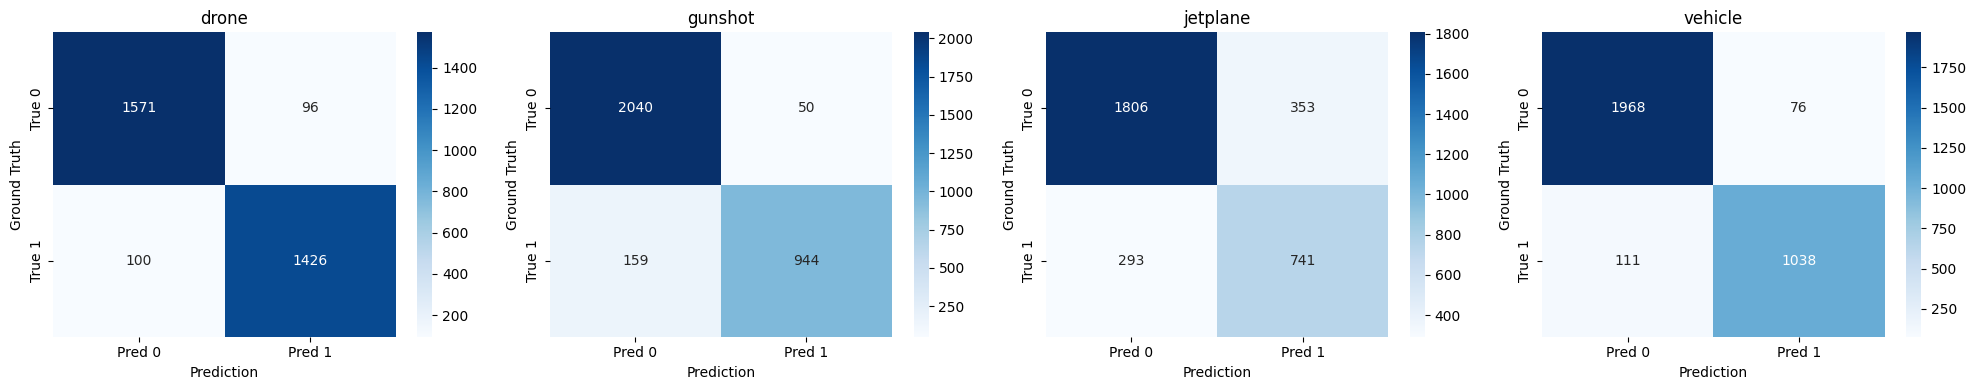

In [35]:
plot_multilabel_confusion_matrices(y_true, y_pred, CLASSES)

In [36]:
def print_confusion_values(y_true, y_pred, classes):
    for i, cls in enumerate(classes):
        tn, fp, fn, tp = confusion_matrix(y_true[:, i], y_pred[:, i]).ravel()
        print(f"\nClass: {cls}")
        print(f" TP: {tp}")
        print(f" TN: {tn}")
        print(f" FP: {fp}")
        print(f" FN: {fn}")

print_confusion_values(y_true, y_pred, CLASSES)        


Class: drone
 TP: 1426
 TN: 1571
 FP: 96
 FN: 100

Class: gunshot
 TP: 944
 TN: 2040
 FP: 50
 FN: 159

Class: jetplane
 TP: 741
 TN: 1806
 FP: 353
 FN: 293

Class: vehicle
 TP: 1038
 TN: 1968
 FP: 76
 FN: 111


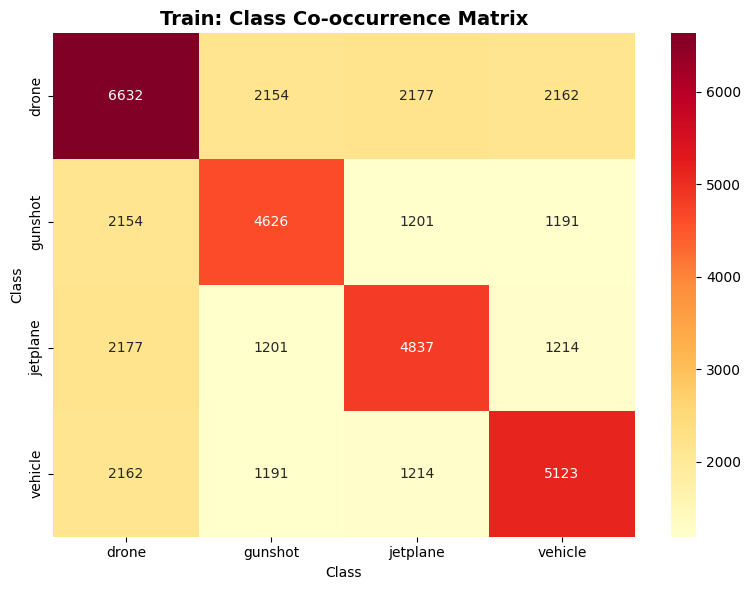

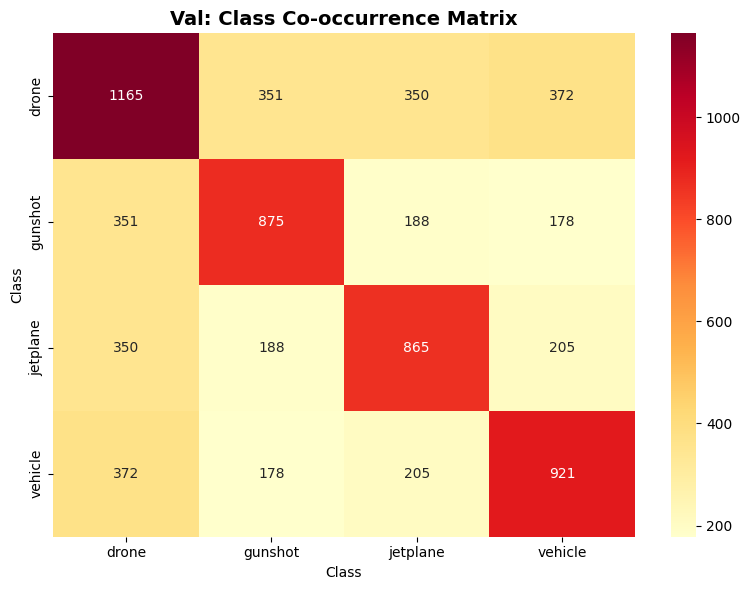

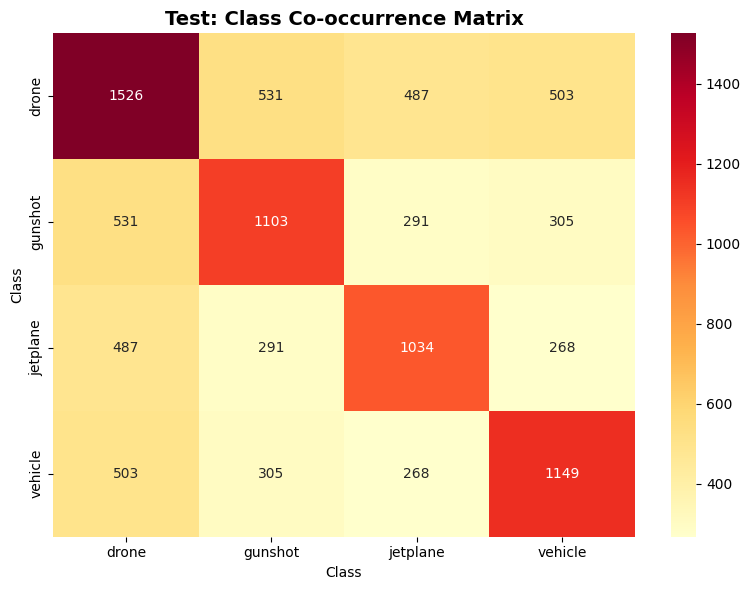

In [37]:
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    co_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)

    for _, row in df.iterrows():
        present = [i for i, cls in enumerate(CLASSES) if row[cls] == 1]
        for i in present:
            for j in present:
                co_matrix[i][j] += 1

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f"{name}: Class Co-occurrence Matrix", fontsize=14, fontweight='bold')
    ax.set_xlabel("Class")
    ax.set_ylabel("Class")
    plt.tight_layout()
    plt.savefig(f"{GENERATED_ROOT}/plot_cooccurrence_{name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()

In [38]:
def generate_stress_test_mixes(class_files, noise_files, output_dir, num_samples=200):
  output_dir = Path(output_dir)
  audio_dir = output_dir / "audio"
  audio_dir.mkdir(parents=True, exist_ok=True)
  rows = []

  for i in tqdm(range(num_samples), desc="Stress test mixes"):
    n_cls = random.choice([2, 3])
    chosen = random.sample(CLASSES, n_cls)
    mix = np.zeros(SAMPLES, dtype=np.float32)
    labels = {cls: 0 for cls in CLASSES}

    for cls in chosen:
      if not class_files[cls]:
        continue

      src = random.choice(class_files[cls])
      y = load_audio_safe(src)
      if y is None:
        continue

      event_len = random.randint(int(0.3 * SR), int(1.5 * SR))
      event_len = min(event_len, len(y), SAMPLES)
      y = pad_or_crop(y, event_len)

      y, _ = random_gain(y, 0.05, 0.4)

      placed, _ = place_randomly(y, SAMPLES)
      mix += placed
      labels[cls] = 1

    if noise_files:
      nf = random.choice(noise_files)
      noise = load_audio_safe(str(nf))
      if noise is not None:
        noise = fit_noise_to_length(noise, SAMPLES)
        snr_db = random.uniform(-5, 3)
        mix = add_noise_at_snr(mix, noise, snr_db)
    else:
      noise = np.random.randn(SAMPLES).astype(np.float32)
      snr_db = random.uniform(-3, 5)
      mix = add_noise_at_snr(mix, noise, snr_db)

    if random.random() < 0.5:
      mix = lowpass_filter(mix, cutoff=random.randint(1500, 3500))
    if random.random() < 0.4:
      mix = highpass_filter(mix, cutoff=random.randint(300, 1000))

    if random.random() < 0.3:
      clip_val = random.uniform(0.3, 0.7)
      mix = np.clip(mix, -clip_val, clip_val)

    mix = normalize_audio(mix)

    fname = f"stress_{i:06d}.wav"
    fpath = str(audio_dir / fname)
    sf.write(fpath, mix, SR)

    row = {"filepath": fpath}
    for cls in CLASSES:
      row[cls] = labels[cls]
    chosen_present = [c for c in CLASSES if labels[c] == 1]
    row["classes_present"] = ",".join(chosen_present)
    row["num_classes"] = len(chosen_present)
    row["hard_mode"] = 2
    rows.append(row)

  df = pd.DataFrame(rows)
  df.to_csv(output_dir / "stress_test_metadata.csv", index=False)
  print(f"Stress test saved: {len(df)} samples")
  return df

stress_class_files = build_split_class_dict(split_df, "test")
stress_dir = Path(GENERATED_ROOT) / "stress_test"

stress_df = generate_stress_test_mixes(
  stress_class_files, noise_files, stress_dir, num_samples=300
)

stress_gen = MultiLabelAudioGenerator(
  stress_df, batch_size=BATCH_SIZE, augment=False,
  shuffle=False, mean=MEAN, std=STD
)

y_stress_true = []
y_stress_pred = []

for i in range(len(stress_gen)):
  X_b, y_b = stress_gen[i]
  p = model.predict(X_b, verbose=0)
  y_stress_true.append(y_b)
  y_stress_pred.append(p)

y_stress_true = np.vstack(y_stress_true)
y_stress_probs = np.vstack(y_stress_pred)
y_stress_pred = (y_stress_probs >= THRESHOLD).astype(int)

print("\n" + "=" * 60)
print("STRESS TEST EVALUATION")
print("=" * 60)
stress_results = evaluate_multilabel(
  y_stress_true, y_stress_pred, y_stress_probs, CLASSES
)

Stress test mixes: 100%|██████████| 300/300 [00:02<00:00, 104.54it/s]


Stress test saved: 300 samples


NameError: name 'THRESHOLD' is not defined